In [1]:
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem")
import scanpy as sc
import pandas as pd

import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/")
import AgaeSMO as AgaeSMO
os.environ['R_HOME'] = '/public/home/stu_wanghaoyu/miniconda3/envs/pyg1/lib/R' 
import matplotlib.patches as patches
import numpy as np

In [2]:
from sklearn import metrics
def supervise_index(adata,predict,real_key):
    
    ARI = metrics.adjusted_rand_score(adata.obs[real_key],adata.obs[predict])
    NMI = metrics.normalized_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    FMS = metrics.fowlkes_mallows_score(adata.obs[real_key],adata.obs[predict])
    AMI = metrics.adjusted_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    HMG = metrics.homogeneity_score(adata.obs[real_key],adata.obs[predict])
    VMS = metrics.v_measure_score(adata.obs[real_key],adata.obs[predict])
    MIS = metrics.mutual_info_score(adata.obs[real_key],adata.obs[predict])
    return {"ARI":ARI,
            "NMI":NMI,
            "FMS":FMS,
            "AMI":AMI,
            "HMG":HMG,
            "VMS":VMS,
            'MIS':MIS}

In [3]:
ls comparison/*/HumanBreastCance*

comparison/STAGATE/HumanBreastCancer.h5ad
comparison/STMGraph/HumanBreastCancer.h5ad
comparison/STMGraph/HumanBreastCancer.ipynb
comparison/deepst/HumanBreastCancer.h5ad
comparison/spaGCN/HumanBreastCancer.h5ad


In [4]:
software_name=["DeepST","SpaGCN","STAGATE","STMGraph","AgaeSMO"]

path=[
    "comparison/deepst/HumanBreastCancer.h5ad",
    "comparison/spaGCN/HumanBreastCancer.h5ad",
    "comparison/STAGATE/HumanBreastCancer.h5ad",
    "comparison/STMGraph/HumanBreastCancer.h5ad",
    "test_2/HumanBreastCancer/HumanBreastCancer_AgaeSMO.h5ad"
]

In [5]:
# groundtruth=pd.read_csv("/public/home/off_liukunpeng/project/7_public_data/Data/2.Mouse_Brain_Anterior/metadata.tsv",sep="\t",header=0,index_col=0)
groundtruth=pd.read_csv("/public/home/off_liukunpeng/project/7_public_data/Data/3.Human_Breast_Cancer/metadata.tsv",sep="\t")
# adata.obs['Ground Truth']=cluser.loc[:,'ground_truth'].to_list()

In [6]:
DeepST_adata__=sc.read_h5ad(path[0])
SpaGCN_adata__=sc.read_h5ad(path[1])
STAGATE_adata_=sc.read_h5ad(path[2])
STMGraph_adata=sc.read_h5ad(path[3])
AgaeSMO_adata___=sc.read_h5ad(path[4])



In [7]:
DeepST_adata__.obs["groundtruth"]=groundtruth.loc[:,'ground_truth'].to_list()
SpaGCN_adata__.obs["groundtruth"]=groundtruth.loc[:,'ground_truth'].to_list()
STAGATE_adata_.obs["groundtruth"]=groundtruth.loc[:,'ground_truth'].to_list()
STMGraph_adata.obs["groundtruth"]=groundtruth.loc[:,'ground_truth'].to_list()
AgaeSMO_adata___.obs["groundtruth"]=groundtruth.loc[:,'ground_truth'].to_list()

In [8]:
DeepST_adata__ARI=supervise_index(DeepST_adata__,"DeepST_refine_domain","groundtruth")['ARI']
SpaGCN_adata__ARI=supervise_index(SpaGCN_adata__,"refined_pred","groundtruth")['ARI']
STAGATE_adata_ARI=supervise_index(STAGATE_adata_,"mclust","groundtruth")['ARI']
STMGraph_adataARI=supervise_index(STMGraph_adata,"refine_mclust","groundtruth")['ARI']
AgaeSMO_adata___ARI=supervise_index(AgaeSMO_adata___,"AgaeSMO","groundtruth")['ARI']

DeepST_adata__ARI=round(DeepST_adata__ARI,4)
SpaGCN_adata__ARI=round(SpaGCN_adata__ARI,4)
STAGATE_adata_ARI=round(STAGATE_adata_ARI,4)
STMGraph_adataARI=round(STMGraph_adataARI,4)
AgaeSMO_adata___ARI=round(AgaeSMO_adata___ARI,4)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default

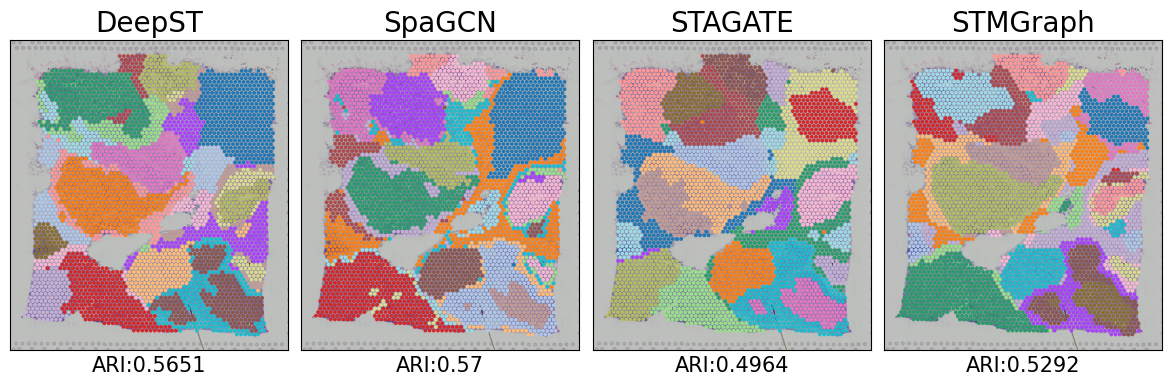

In [29]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(1,4,figsize=(12,4))
s_1=10

sc.pl.spatial(DeepST_adata__, basis='spatial', color='DeepST_refine_domain',ax=axs[0], title='DeepST', s=s_1, show=False)
sc.pl.spatial(SpaGCN_adata__, basis='spatial', color='refined_pred',        ax=axs[1], title="SpaGCN", s=s_1, show=False)
sc.pl.spatial(STAGATE_adata_, basis='spatial', color='mclust',              ax=axs[2], title="STAGATE", s=s_1, show=False)
sc.pl.spatial(STMGraph_adata, basis='spatial', color='refine_mclust',       ax=axs[3], title="STMGraph", s=s_1, show=False)
# sc.pl.spatial(AgaeSMO_adata___, basis='spatial', color='AgaeSMO',       ax=axs[4], title="AgaeMSO", s=s_1, show=False)


plt.subplots_adjust(left=0.02, bottom=0.1, right=0.98, top=0.90, wspace=0.05, hspace=0.05)
# 3,7
# for i in axs:
for j in axs:
    j.set_xlabel("")
    j.set_ylabel("")
    j.set_title(j.title.get_text(), fontsize=20)
    
    # j.invert_yaxis()
    legend = j.legend()
    # legend.set_visible(False)  # 隐藏图例
for i in range(4):
    axs[i].legend().set_visible(False)
# axs[4].legend(ncol=2,bbox_to_anchor=(1.8, 1))


axs[0].set_xlabel(f"ARI:{DeepST_adata__ARI}", fontsize=15)
axs[1].set_xlabel(f"ARI:{SpaGCN_adata__ARI}", fontsize=15)
axs[2].set_xlabel(f"ARI:{STAGATE_adata_ARI}", fontsize=15)
axs[3].set_xlabel(f"ARI:{STMGraph_adataARI}", fontsize=15)
# axs[4].set_xlabel(f"ARI:{AgaeSMO_adata___ARI}", fontsize=15)
fig.savefig("plot/fig5_HBC.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


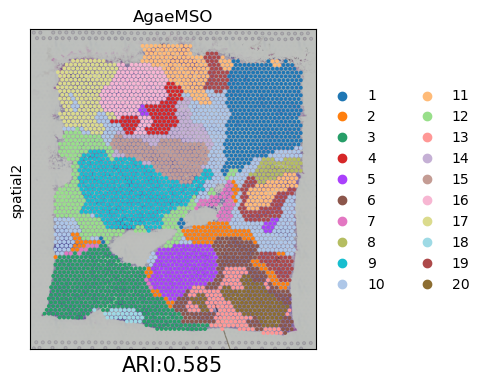

In [30]:
fig,axs=plt.subplots(1,figsize=(6,4))
sc.pl.spatial(AgaeSMO_adata___, basis='spatial', color='AgaeSMO', ax=axs, title="AgaeMSO", s=s_1, show=False)
plt.subplots_adjust(left=0.02, bottom=0.1, right=0.8, top=0.90, wspace=0.05, hspace=0.05)
axs.set_xlabel(f"ARI:{AgaeSMO_adata___ARI}", fontsize=15)
fig.savefig("plot/fig5_HBC_AgaeSMO.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


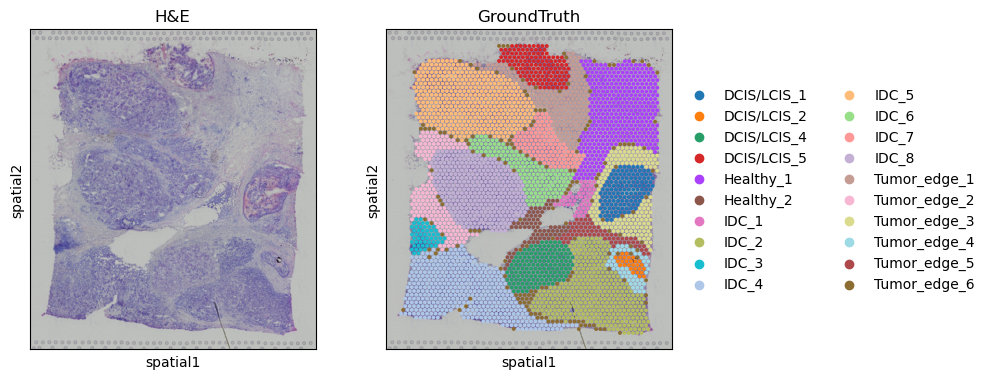

In [17]:
fig,axs=plt.subplots(1,2,figsize=(12,4))
sc.pl.spatial(AgaeSMO_adata___, basis='spatial', ax=axs[0],title="H&E", s=s_1, show=False)
sc.pl.spatial(AgaeSMO_adata___, basis='spatial', color='groundtruth', ax=axs[1],title="GroundTruth", s=s_1, show=False)
plt.subplots_adjust(left=0.02, bottom=0.1, right=0.6, top=0.90, wspace=0.05, hspace=0.05)
plt.savefig("plot/fig5_HBC_GroundTruth.png",dpi=600)

In [18]:
import seaborn as sns
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  return df
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show() 

In [19]:
df_all=[]
for n,i in enumerate(set(AgaeSMO_adata___.obs["AgaeSMO"])):
    alpha=AgaeSMO_adata___.obsm["alpha"][AgaeSMO_adata___.obs["AgaeSMO"]==i,:]
    # print(alpha.shape)
    df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='H&E')
    df["cluster"]=i
    df_all.append(df)
df_all = pd.concat(df_all, ignore_index=True)

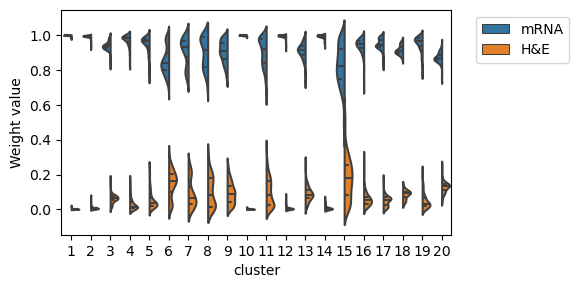

In [21]:
fig,ax=plt.subplots(1,figsize=(6,3))
sns.violinplot(data=df_all,ax=ax, x="cluster", y="Weight value", hue="Modality", split=True, inner="quart")

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.8, top=0.90, wspace=0.05, hspace=0.05)
ax.legend( ncol=1,loc= 'upper right' ,fontsize=10,bbox_to_anchor=(1.32, 1))
fig.savefig("plot/fig5_HBC_b.png",dpi=600)

In [31]:

# from matplotlib.lines import Line2D
# fig,ax=plt.subplots(1,figsize=(8,3))
# for n,i in enumerate(set(AgaeSMO_adata___.obs["AgaeSMO"])):
#     alpha=AgaeSMO_adata___.obsm["alpha"][AgaeSMO_adata___.obs["AgaeSMO"]==i,:]
#     # print(alpha.shape)
#     df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='H&E')
#     # print(df)
#     sns.violinplot(data=df,ax=ax,x=n+1,y='Weight value', hue="Modality",
#                 split=True, inner="quart", linewidth=1)
    
#     ax.scatter(n,0,c=AgaeSMO_adata___.uns["AgaeSMO_colors"][n])
# ax.legend().set_visible(False)
# legend_elements = [
#     Line2D([0], [0], marker='s', color='w', label='mRNA',       markerfacecolor="#44739d", markersize=10),
#     Line2D([0], [0], marker='s', color='w', label='H&E',       markerfacecolor="#b2753d", markersize=10),
# ]
# plt.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.90, wspace=0.05, hspace=0.05)
# ax.legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
# fig.savefig("plot/fig5_HBC_b.png",dpi=600)

In [33]:

adata=AgaeSMO_adata___.copy()
his_key=list(adata.uns["spatial"].keys())[0]
#int spot xy in his
adata.obsm["spatial_px"]=adata.obsm["spatial"]*adata.uns["spatial"][his_key]["scalefactors"]["tissue_hires_scalef"]
adata.obsm["spatial_px"]=adata.obsm["spatial_px"].astype(int)
# plot_spot_his(adata.uns["spatial"][his_key]["images"]["hires"],adata.obsm["spatial_px"])
#calculate box xy
r=8
adata=AgaeSMO.calculate_box(adata,adata.obsm["spatial_px"],r)
adata.obsm['patch']=AgaeSMO.his_path(adata,adata.uns["spatial"][his_key]["images"]["hires"])
adata.obsm["patch_flattern"]=adata.obsm["patch"].reshape(adata.obsm["patch"].shape[0],-1)


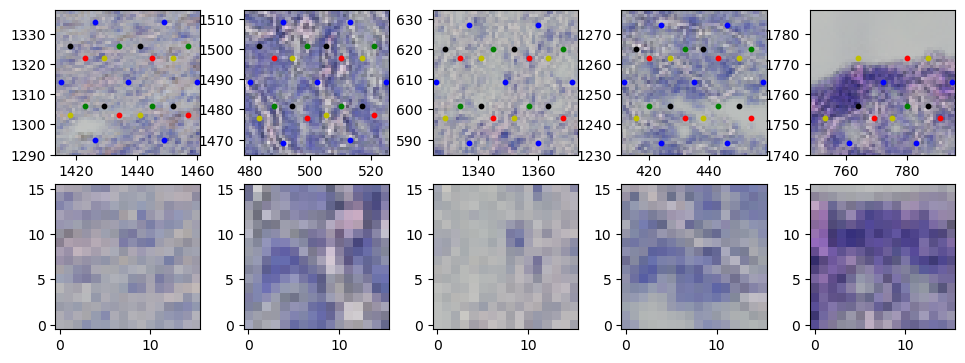

In [34]:
AgaeSMO.check_patch_his(adata,his_key,r)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.90, wspace=0.3, hspace=0.2)
plt.savefig("plot/fig5_patch.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


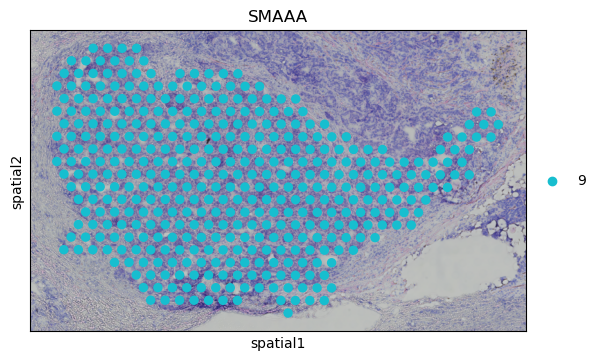

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


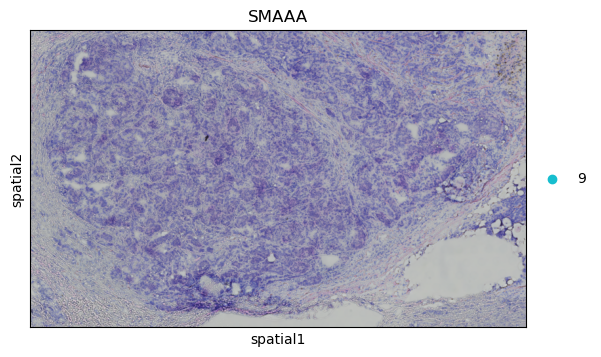

In [37]:
sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==9,:],color="AgaeSMO")
sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==9,:],color="AgaeSMO",size=0)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


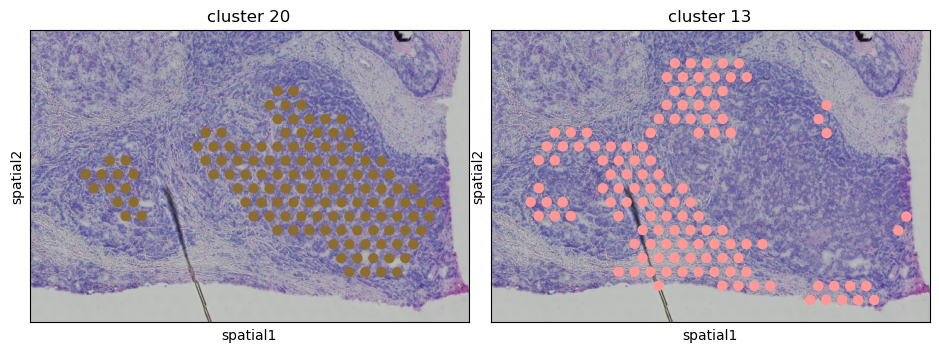

In [44]:
fig,axs=plt.subplots(1,2,figsize=(10,4))
sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==20,:],color="AgaeSMO",title="cluster 20",ax=axs[0],show=False, crop_coord=[12500, 20000, 17500, 22500])
# sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==20,:],color="AgaeSMO",size=0,title="H&E",ax=axs[1,1],show=False, crop_coord=[12000, 16000, 18500, 22000])
sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==13,:],color="AgaeSMO",title="cluster 13",ax=axs[1],show=False, crop_coord=[12500, 20000, 17500, 22500])
# sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==13,:],color="AgaeSMO",size=0,title="H&E",ax=axs[1,0],show=False, crop_coord=[12500, 20000, 17500, 22500])

plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.05)
for i in axs:

    i.legend().set_visible(False)
fig.savefig("plot/fig5_cluster20-13.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


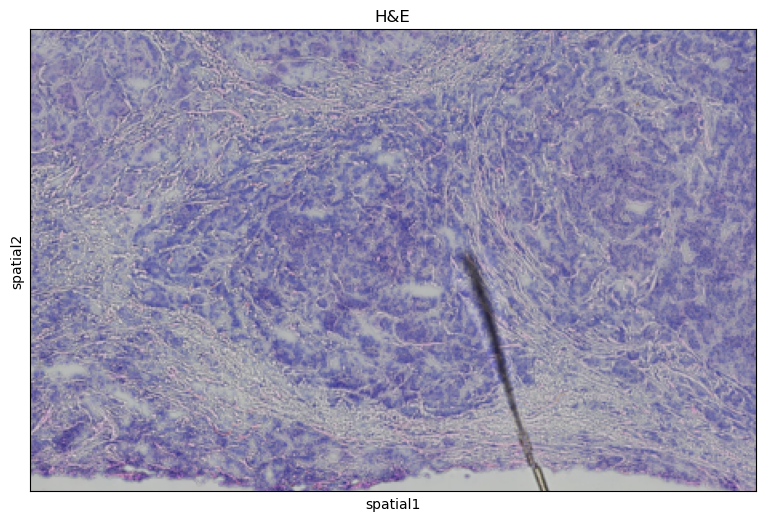

In [20]:
fig,axs=plt.subplots(1,figsize=(10,6))
sc.pl.spatial(AgaeSMO_adata___[AgaeSMO_adata___.obs["AgaeSMO"]==13,:],color="AgaeSMO",size=0,title="H&E",show=False, crop_coord=[11500, 17000, 18500, 22000],ax=axs)
axs.legend().set_visible(False)
fig.savefig("plot/fig5_H&E.png",dpi=600)